# Normalizacao não funciona muito bem com o prophet, preferivel utilizar os dados originais

In [1]:
from prophet import Prophet
from prophet.diagnostics import cross_validation,performance_metrics
from prophet.plot import plot_cross_validation_metric
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from statsmodels.tools.eval_measures import rmse

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_excel(
    "/home/henrique/IC-Gasto-Fotovoltaico-main/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

df = df.head()

df1 = df.transpose()
df = df1.rename(columns=df1.iloc[0])
df.drop("UC", inplace=True, axis=0)
df.dropna(inplace=True)

df.index.freq = "MS"

df.reset_index(inplace=True)
df = df.rename(columns={"index": "DS"})

df.columns = ["ds", "y1", "y2", "y3", "y4", "y5"]

df["y1"] = df["y1"].astype(int)
df["y2"] = df["y2"].astype(int)
df["y3"] = df["y3"].astype(int)
df["y4"] = df["y4"].astype(int)
df["y5"] = df["y5"].astype(int)

In [3]:
values = df["y1"].values
values = values.reshape((len(values), 1))

scaler = MinMaxScaler(feature_range=(0, 1))
scaler = scaler.fit(values)

df_normalized = scaler.transform(values)

In [4]:
df["y"] = df_normalized

In [5]:
m = Prophet()

m.fit(df)

future = m.make_future_dataframe(periods=0,freq='MS')

forecast = m.predict(future)

forecast.head()

14:34:08 - cmdstanpy - INFO - Chain [1] start processing
14:34:08 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2019-06-01,0.529215,-0.119205,0.380368,0.529215,0.529215,-0.389412,-0.389412,-0.389412,-0.389412,-0.389412,-0.389412,0.0,0.0,0.0,0.139803
1,2019-07-01,0.526435,-0.095568,0.408936,0.526435,0.526435,-0.360235,-0.360235,-0.360235,-0.360235,-0.360235,-0.360235,0.0,0.0,0.0,0.166199
2,2019-08-01,0.523562,-0.001335,0.509265,0.523562,0.523562,-0.269637,-0.269637,-0.269637,-0.269637,-0.269637,-0.269637,0.0,0.0,0.0,0.253925
3,2019-09-01,0.520689,0.138249,0.627328,0.520689,0.520689,-0.149704,-0.149704,-0.149704,-0.149704,-0.149704,-0.149704,0.0,0.0,0.0,0.370985
4,2019-10-01,0.517909,0.183598,0.675097,0.517909,0.517909,-0.086822,-0.086822,-0.086822,-0.086822,-0.086822,-0.086822,0.0,0.0,0.0,0.431087


<Axes: xlabel='ds'>

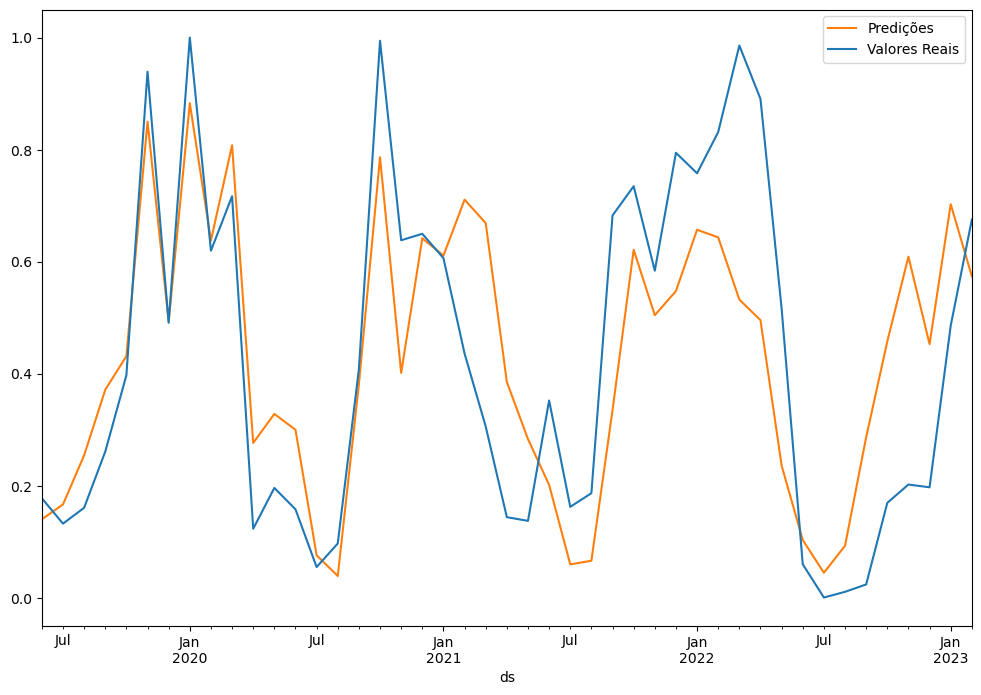

In [6]:
ax = forecast.plot(x='ds', y='yhat', label='Predições', legend=True, figsize=(12,8), color="#ff7f0e")
df.plot(x='ds',y='y',label='Valores Reais',legend=True,ax=ax,color="#1f77b4")
# plt.savefig("ProphetPredAndFuturePred.png")

In [7]:
df_cv = cross_validation(m,initial="730 days",period="180 days",horizon="365 days",parallel="processes")

14:34:08 - cmdstanpy - INFO - Chain [1] start processing
14:34:08 - cmdstanpy - INFO - Chain [1] start processing
14:34:08 - cmdstanpy - INFO - Chain [1] done processing
14:34:08 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
performance_metrics(df_cv)

,horizon,mse,rmse,mae,mdape,smape,coverage
0,28 days,0.385675,0.621027,0.550038,0.617062,0.977240,0.0
1,57 days,0.358290,0.598574,0.477756,0.505011,0.813780,0.0
2,59 days,0.123794,0.351844,0.300371,0.351333,0.446701,0.0
3,88 days,0.138850,0.372625,0.346481,0.450970,0.524944,0.0
4,89 days,0.050944,0.225709,0.225156,0.412886,0.456733,0.0
5,118 days,0.039246,0.198107,0.191953,0.323513,0.403548,0.0
6,120 days,0.057318,0.239412,0.224940,2.674662,0.819949,0.0
7,149 days,0.047673,0.218340,0.170388,2.606996,0.742891,0.5
8,150 days,0.036355,0.190670,0.150686,inf,1.021858,0.5
9,180 days,0.074222,0.272438,0.272394,inf,1.200173,0.0


In [9]:
values = forecast['yhat'].values
values = values.reshape((len(values), 1))

inversed = scaler.inverse_transform(values)

df["inversed"] = inversed

<Axes: xlabel='ds'>

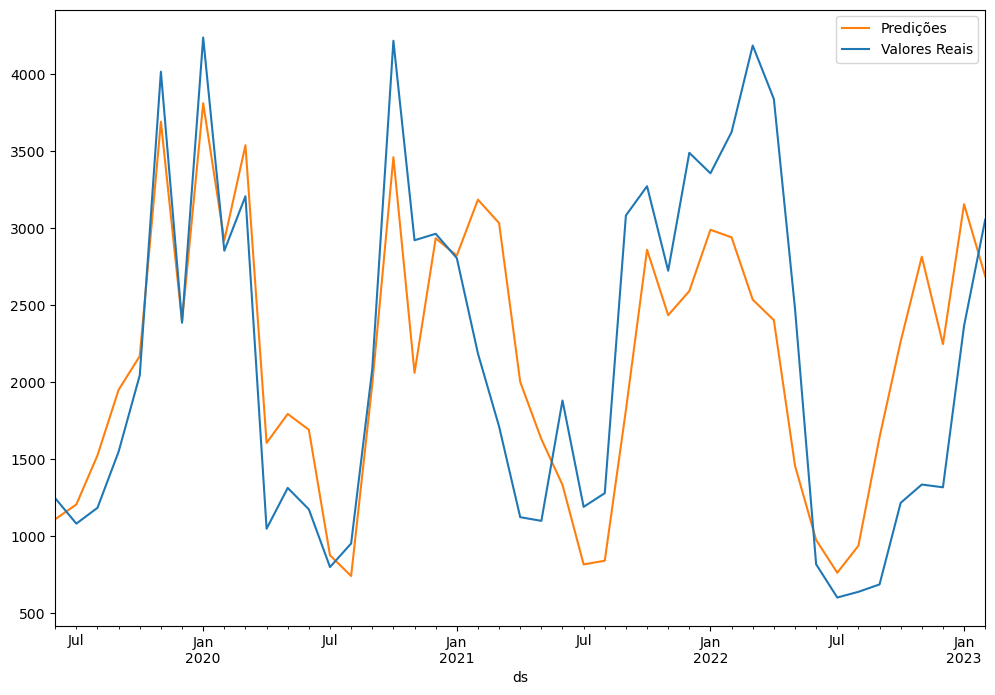

In [10]:
ax = df.plot(x='ds', y='inversed', label='Predições', legend=True, figsize=(12,8), color="#ff7f0e")
df.plot(x='ds',y='y1',label='Valores Reais',legend=True,ax=ax,color="#1f77b4")
# plt.savefig("ProphetPredAndFuturePred.png")

In [11]:
error = rmse(df['y1'], df['inversed'])
print(f'RMSE Error: {error:11.10}')

RMSE Error: 705.6497808


In [12]:
m = Prophet()

m.fit(df)

future = m.make_future_dataframe(periods=24,freq='MS')

forecast = m.predict(future)

14:34:08 - cmdstanpy - INFO - Chain [1] start processing
14:34:09 - cmdstanpy - INFO - Chain [1] done processing


<Axes: xlabel='ds'>

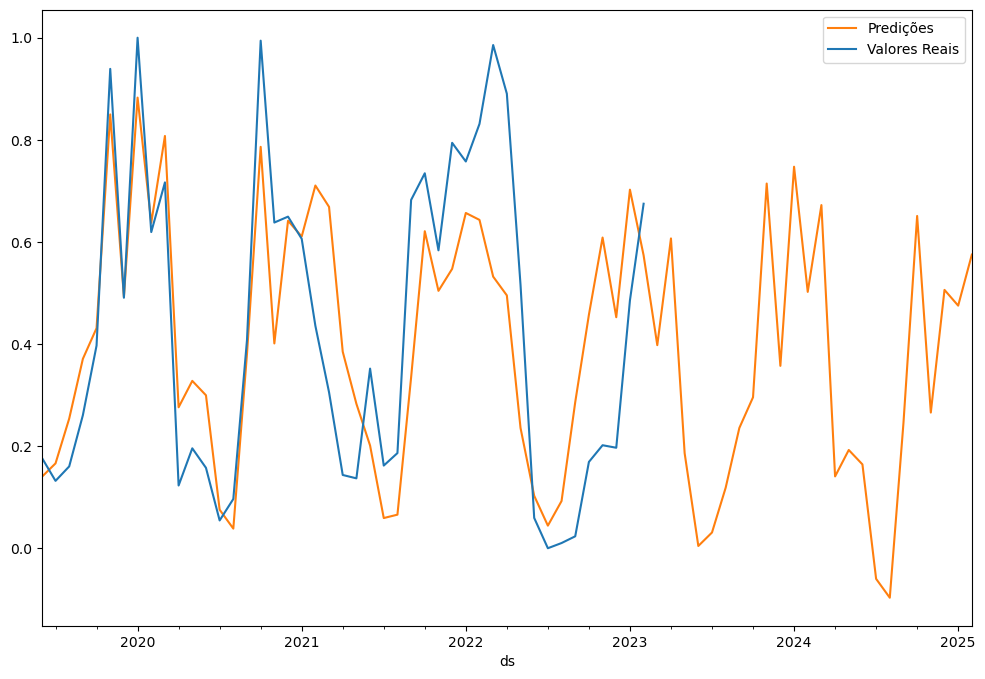

In [13]:
ax = forecast.plot(x='ds', y='yhat', label='Predições', legend=True, figsize=(12,8), color="#ff7f0e")
df.plot(x='ds',y='y',label='Valores Reais',legend=True,ax=ax,color="#1f77b4")
# plt.savefig("ProphetPredAndFuturePred.png")

In [14]:
values = forecast['yhat'].values
values = values.reshape((len(values), 1))

inversed = scaler.inverse_transform(values)

df_inversed = pd.DataFrame(inversed)

In [15]:
df_inversed

,0
0,1109.604959
1,1205.633691
2,1524.779623
3,1950.644545
4,2169.296012
...,...
64,2968.908195
65,1567.813697
66,2441.981526
67,2329.790139


In [16]:
ax = df.plot(x='ds',y='y1',label='Valores Reais',legend=True,ax=ax,color="#1f77b4")
df_inversed.plot(x='ds', y=0, label='Predições', legend=True, figsize=(12,8), color="#ff7f0e")
# plt.savefig("ProphetPredAndFuturePred.png")

KeyError: 'ds'